# CatBoost Model Development
### Notebook Done By: Anuf/Cliff/Jonathan

This notebook contains the development process for the CatBoost model, which would end up being the model used for this project. This notebook covers the process of developing, evaluating, and refining this model.

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [2]:
# Loading train/test data

base_path = '../../data/modelling/'

X_train = pd.read_csv(base_path + 'X_train.csv', index_col=0)
X_test = pd.read_csv(base_path + 'X_test.csv', index_col=0)
y_train = pd.read_csv(base_path + 'y_train.csv', index_col=0)['log_price']
y_test = pd.read_csv(base_path + 'y_test.csv', index_col=0)['log_price']

In [3]:
# Fitting the base model

model = CatBoostRegressor(random_state=42, verbose=0)
model.fit(X_train, y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [4]:
# Predicting values from test data with the base model

y_pred = model.predict(X_test)

In [5]:
# Reviewing evaluation metrics for the base model

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 0.174678162347934
RMSE: 0.2473213293235481
R2: 0.839706805599312


The evaluation metrics suggest that the base CatBoost model is more accurate than the base LightGBM model, but very marginally less accurate than the tuned LightGBM model.

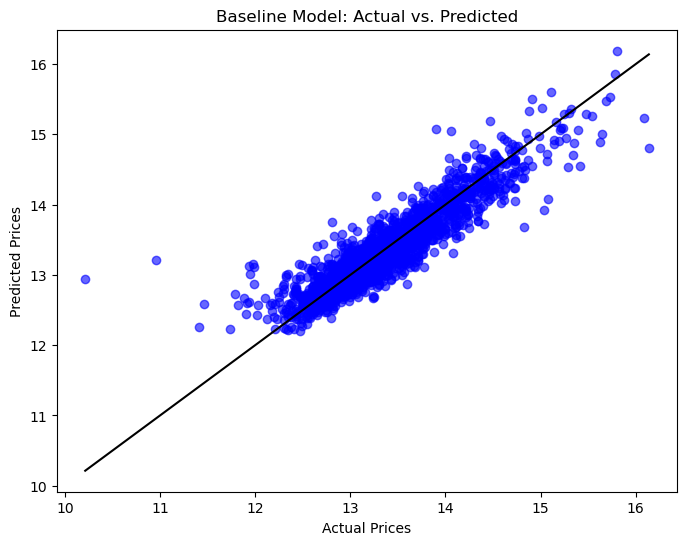

In [6]:
# Visualising how predicted values from the base model differ from actual values

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Baseline Model: Actual vs. Predicted')
plt.show()

The chart above shows that the model is accurate in predicting lower/middle-ranged house prices, with some limitations as seen in the deviations when predicting higher-value property prices.

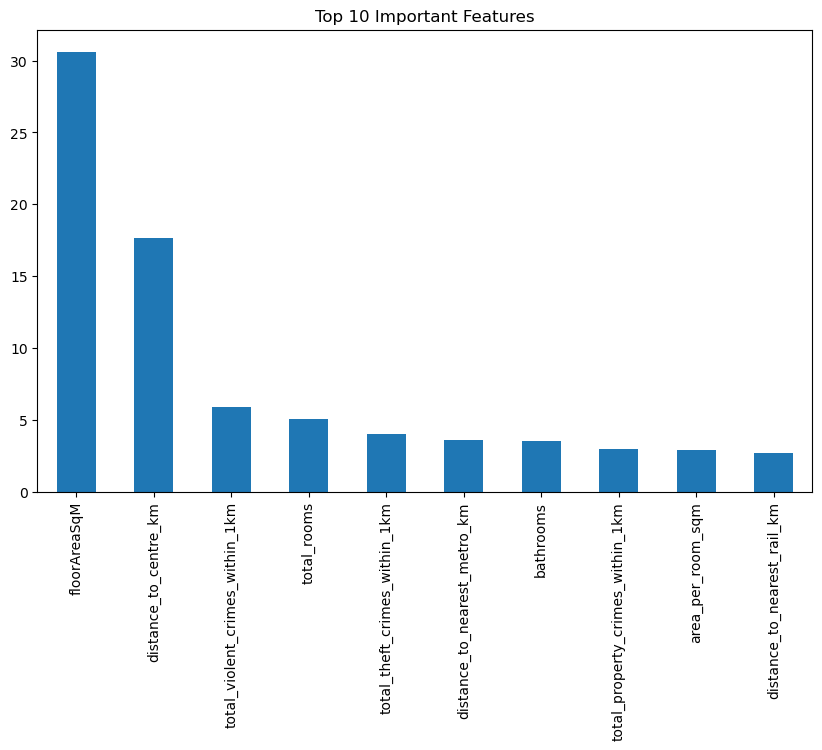

In [7]:
# Reviewing most important features in the base model

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

The visualisation above shows that the most important features in this model mostly consist of structural features such as floor area and room counts, as well as spatial features such as distance to amenities and total crimes within 1km.

Since the base CatBoost model is slightly less accurate than the tuned LightGBM, tuning this model may increase accuracy.

In [8]:
# Tuning the model and fitting it

model_tuned = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=5,
    subsample=0.6,
    random_state=42,
    verbose=0
)

model_tuned.fit(X_train, y_train)

CatBoostRegressor(depth=8, iterations=1000, l2_leaf_reg=5, learning_rate=0.1, loss_function='RMSE', random_state=42, subsample=0.6, verbose=0)

In [9]:
# Predicting values from the test data with the tuned model

y_pred_tuned = model_tuned.predict(X_test)

In [10]:
# Reviewing evaluation metrics for the tuned model and comparing them to those of the base model

mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))
r2_base = r2_score(y_test, y_pred)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print('=== Baseline Model ===')
print('MAE:', mae_base)
print('RMSE:', rmse_base)
print('R2:', r2_base)

print('=== Tuned Model ===')
print('MAE:', mae_tuned)
print('RMSE:', rmse_tuned)
print('R2:', r2_tuned)

=== Baseline Model ===
MAE: 0.174678162347934
RMSE: 0.2473213293235481
R2: 0.839706805599312
=== Tuned Model ===
MAE: 0.1720839271202384
RMSE: 0.24412647991446743
R2: 0.8438213308819313


After tuning the model multiple times, ideal parameters for this model have been found, as the evaluation metrics for the tuned model are an upgrade from all the other models tested in this project.

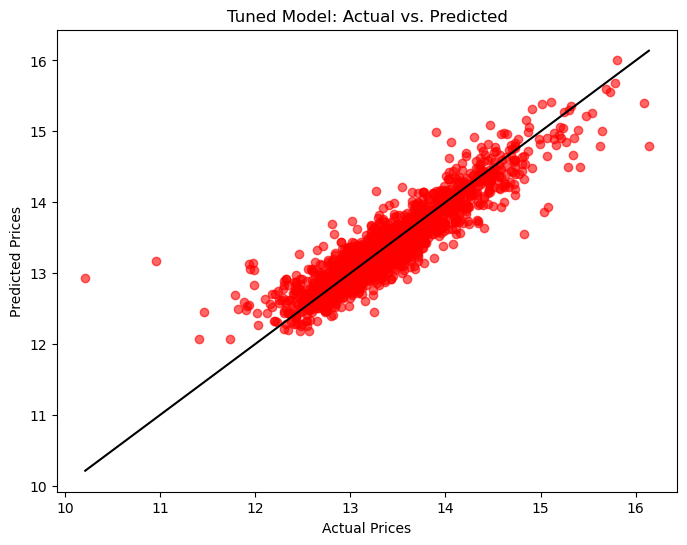

In [11]:
# Visualising how predicted values from the tuned model differ from actual values

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tuned, alpha=0.6, color='red')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='black')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Tuned Model: Actual vs. Predicted')
plt.show()

The chart above shows that the tuned model is accurate in predicting lower/middle-ranged house prices much like the base model, with also some limitations as seen in the deviations when predicting higher-value property prices. However, tuning the model slightly improved the accuracy in predicting higher-value property prices.

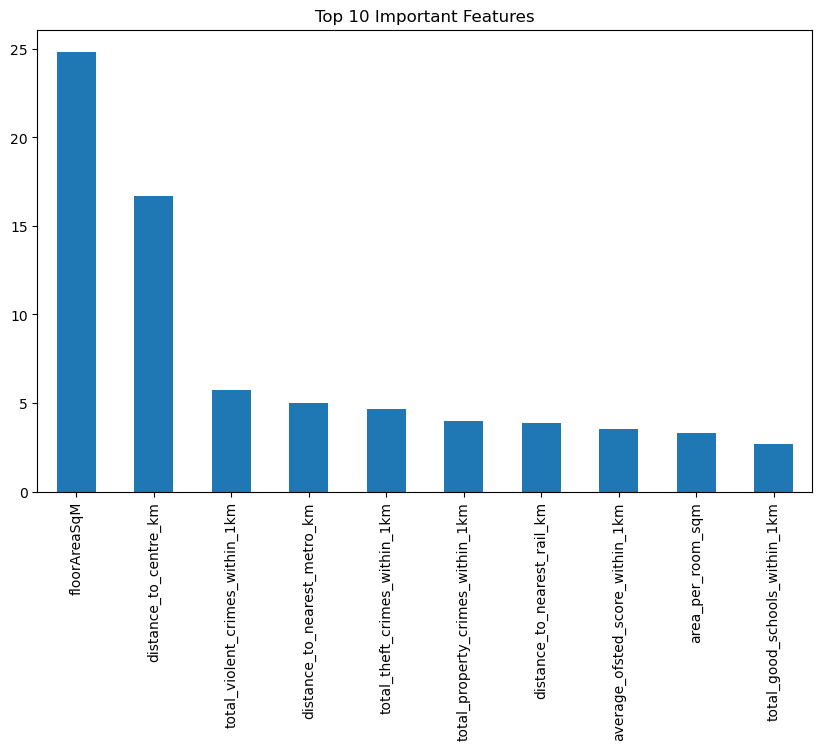

In [12]:
# Reviewing most important features in the tuned model

importance = pd.Series(model_tuned.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importance.head(10).plot(kind='bar')
plt.title('Top 10 Important Features')
plt.show()

The visualisation above shows that the most important features in this tuned model mostly consist of structural features such as floor area, as well as spatial features such as distance to amenities and total crimes/good-schools within 1km.

In [13]:
# Dumping the tuned model to be used in the demo

joblib.dump(model_tuned, "../../models/property_price_predictor.pkl")

['../../models/property_price_predictor.pkl']

In [14]:
# Dumping feature columns to be used in user input processing in the demo

joblib.dump(X_train.columns.tolist(), "../../models/feature_columns.pkl")

['../../models/feature_columns.pkl']

Seeing as though the tuned CatBoost model outperforms all other models tested in this project, it and feature columns will be dumped into ```.pkl``` files which will be important in the demo and user input processing.

The next notebook is ```notebooks/demo.ipynb```.